In [1]:
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import os
import copy
import sys 
sys.path.append("..")
import scipy

In [2]:
import src.model_systems as model_systems
import src.helpers as helpers
import src.potentials as potentials
import src.diffusion_map as diffusion_map

# Make four cluster data

In [14]:
# each point is a column vector
d = 2 
N = 100
N_cluster = 5 
sig = 0.1*np.eye(d)
means = [np.array([1.0,0.0]), np.array([0.0,1.0]), np.array([-1.0,0.0]), np.array([0.0,-1.0]), np.array([0.0,0.0])]
# means = [means[i].reshape((2,1)) for i in range(N_cluster)]

In [4]:
# data 

data = []
labels = [] 
for i in range(N_cluster): 
    cluster = np.random.multivariate_normal(means[i].flatten(), sig, N).T
    label = i*np.ones(N)
    data.append(cluster)
    labels.append(label)
data = np.hstack(data)
labels = np.hstack(labels)

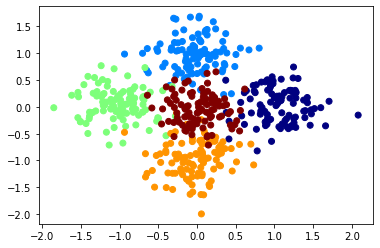

In [5]:
# plot 
plt.scatter(data[0,:], data[1,:], c=labels, cmap='jet')

# Load Class

In [3]:
nmap3 = diffusion_map.NeumannMap(alpha=1.0,epsilon=0.5,num_evecs=2)
subgraph_inds = ~(labels == 1.0)
subgraph_complement_inds = np.linspace(0,500,101, dtype=int)
inds = np.ones(labels.shape[0], dtype=bool)
inds[subgraph_complement_inds[:-1]] = False
nmap3.construct_generator(data,inds)
L3 = nmap3.get_generator()
nmap, nevecs3, nevals3 = nmap3._construct_diffusion_coords(L3)

NameError: name 'labels' is not defined

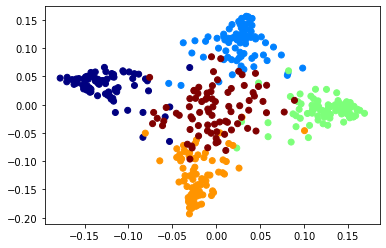

In [7]:
plt.scatter(nmap[:,0], nmap[:,1], c=labels[inds], cmap='jet')

## Compare vs diffusion map 

In [8]:
dmap3 = diffusion_map.DiffusionMap(alpha=1.0,epsilon=0.5,num_evecs=2)
dmap3.construct_generator(data[:,inds])
L_dmap = dmap3.get_generator()
dmap, devecs3, devals3 = nmap3._construct_diffusion_coords(L3)

done with kernel!


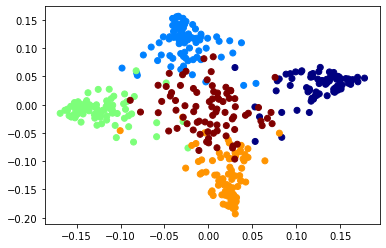

In [11]:
plt.scatter(dmap[:,0], dmap[:,1], c=labels[inds], cmap='jet')

# Spectral clustering

In [146]:
# Parameters for the Gaussian clusters
mean1 = np.random.rand(2) * 10  # Random mean for the first cluster
cov1 = 0.4*np.eye(2)  # Identity matrix as covariance for the first cluster

mean2 = np.random.rand(2) * 10  # Random mean for the second cluster
cov2 = 0.1*np.eye(2)  # Identity matrix as covariance for the second cluster

mean1 = np.array([0,0])
mean2 = np.array([4,0])
cov1 = 1.5*np.eye(2)
cov2 = 0.1*np.eye(2)

In [147]:
# Generate 100 points from each Gaussian cluster
cluster1 = np.random.multivariate_normal(mean1, cov1, 1000)
cluster2 = np.random.multivariate_normal(mean2, cov2, 100)

# Combine the clusters to form the dataset
dataset = np.vstack((cluster1, cluster2))

# Optionally, create labels for the clusters
labels = np.array([0]*1000 + [1]*100)

print("Dataset shape:", dataset.shape)
print("Labels shape:", labels.shape)

Dataset shape: (1100, 2)
Labels shape: (1100,)


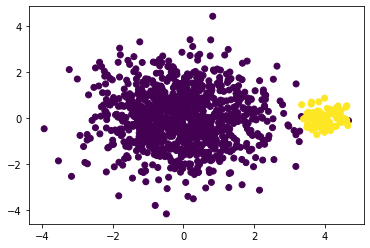

In [148]:
plt.scatter(dataset[:, 0], dataset[:, 1], c=labels, cmap=)

In [149]:
# Select 20 random indices from the dataset
marked_points = np.random.choice(1100, 20, replace=False)

# Create a boolean vector of size 200 with all True values
boolean_vector = np.ones(1100, dtype=bool)

# Set the selected indices to False
boolean_vector[marked_points] = False

## DMap:

In [182]:
# Fiedler vector: 
dmap = diffusion_map.DiffusionMap(alpha=0.0,epsilon=1.0,num_evecs=15, n_neigh=20)
dmap.construct_generator(dataset[boolean_vector].T)
L_dmap = dmap.get_generator()
dmap, devecs3, devals3 = dmap._construct_diffusion_coords(L_dmap)

done with kernel!
computing eigvec matrix


In [151]:
spectral_labels = dmap[:,0] > np.mean(dmap[:,0])

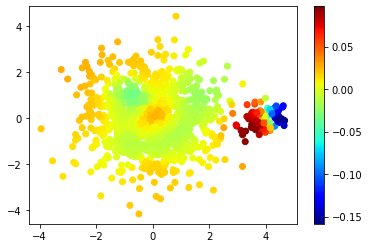

In [229]:
plt.scatter(dataset[boolean_vector,0], dataset[boolean_vector,1], c=devecs3[:,10], cmap='jet')
plt.colorbar()

## Nmap:

In [245]:
# Fiedler vector: 
nmap = diffusion_map.NeumannMap(alpha=0.0,epsilon=1.0,num_evecs=15, delta=0.8, n_neigh=20)
nmap.construct_generator(dataset.T, boolean_vector)
L_nmap = nmap.get_generator()
nmap, nevecs3, nevals3 = nmap._construct_diffusion_coords(L_nmap)

computing eigvec matrix


In [3]:
dataset.shape

NameError: name 'dataset' is not defined

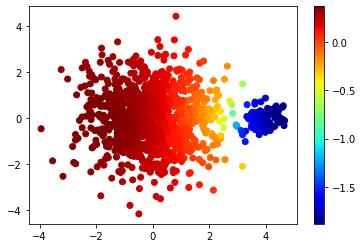

In [247]:
plt.scatter(dataset[boolean_vector,0], dataset[boolean_vector,1], c=nmap[:,0], cmap='jet')
plt.colorbar()

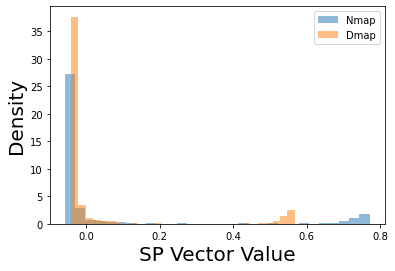

In [110]:
# Plot histograms
plt.hist(nmap[:,0], bins=30, alpha=0.5, label='Nmap', density=True)
plt.hist(dmap[:,0], bins=30, alpha=0.5, label='Dmap', density=True)

# Add labels and legend
plt.xlabel('SP Vector Value', fontsize=20)
plt.ylabel('Density', fontsize=20)
plt.legend()

# Show plot
# plt.savefig("Histogram of Fiedler Vectors.png")

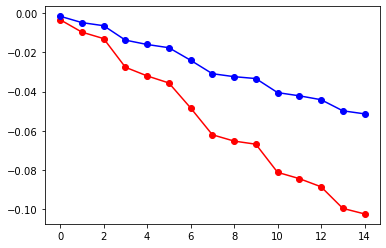

In [216]:
plt.plot(devals3, 'ro-')
plt.plot(nevals3, 'bo-')

In [150]:
# save experiment 
np.savez('clusters_experiment.npz', dataset=dataset, labels=labels, boolean_vector=boolean_vector, \
         dmap=dmap, devecs3=devecs3, devals3=devals3, nmap=nmap, nevecs3=nevecs3, nevals3=nevals3, \
            alpha=0.0, epsilon=1.0, num_evecs=10)

NameError: name 'devecs3' is not defined

In [3]:
clusters_experiment = np.load('gaussian_clusters/clusters_experiment.npz', allow_pickle=True)
dataset = clusters_experiment['dataset']
labels = clusters_experiment['labels']
boolean_vector = clusters_experiment['boolean_vector']
dmap = clusters_experiment['dmap']
nmap = clusters_experiment['nmap']

In [4]:
dataset.shape

(1100, 2)

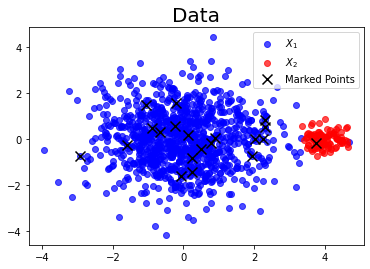

In [5]:
# Plot the dataset
plt.scatter(dataset[:1000, 0], dataset[:1000, 1], label = '$X_1$', color = 'blue', alpha=0.7)
plt.scatter(dataset[1000:, 0], dataset[1000:, 1], label = '$X_2$', color = 'red', alpha=0.7)
plt.scatter(dataset[~boolean_vector, 0], dataset[~boolean_vector, 1], color='black', alpha=1.0, s=100, marker='x', label='Marked Points')
plt.legend()
plt.title("Data", fontsize=20)
plt.savefig('gaussian_clusters.png')

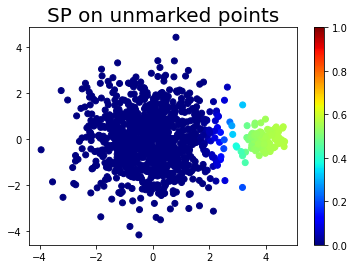

In [167]:
plt.Figure(figsize=(12,12))
plt.scatter(dataset[boolean_vector, 0], dataset[boolean_vector, 1], c=dmap[:,0], cmap='jet', vmin=0, vmax=1.0)
plt.title('SP on unmarked points', fontsize=20)
plt.colorbar()
plt.savefig("SP vector")

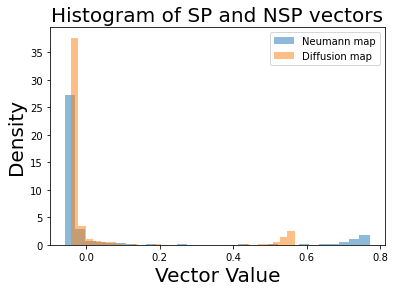

In [168]:
plt.hist(nmap[:,0], bins=30, alpha=0.5, label='Neumann map', density=True)
plt.hist(dmap[:,0], bins=30, alpha=0.5, label='Diffusion map', density=True)
plt.title('Histogram of SP and NSP vectors', fontsize=20)
plt.xlabel('Vector Value', fontsize=20)
plt.ylabel('Density', fontsize=20)
plt.legend()
plt.savefig('Histogram of SP and NSP vectors')

# Compute over random labels 

In [6]:
from tqdm import tqdm
from scipy.stats import entropy

def random_labels_experiment(dataset, n_marks):
    # Select 20 random indices from the dataset
    marked_points = np.random.choice(1100, n_marks, replace=False)
    boolean_vector = np.ones(1100, dtype=bool)
    # Set the selected indices to False
    boolean_vector[marked_points] = False
    # Fiedler vector:
    dmap = diffusion_map.DiffusionMap(alpha=0.0,epsilon=1.0,num_evecs=1, n_neigh=20)
    dmap.construct_generator(dataset[boolean_vector].T)
    L_dmap = dmap.get_generator()
    dmap, _, _ = dmap._construct_diffusion_coords(L_dmap)
    # Fiedler vector: 
    nmap = diffusion_map.NeumannMap(alpha=0.0,epsilon=1.0,num_evecs=1, delta=0.5, n_neigh=20)
    nmap.construct_generator(dataset.T, boolean_vector)
    L_nmap = nmap.get_generator()
    nmap, _, _ = nmap._construct_diffusion_coords(L_nmap)
    return dmap, nmap, boolean_vector

def get_embeddings(n_marks):
    embeddings = []
    for _ in tqdm(range(100)): 
        dmap, nmap, boolean_vector = random_labels_experiment(dataset, n_marks)
        embeddings.append((dmap, nmap, boolean_vector))
    return embeddings

def compute_cluster_separator(embeddings, labels):
    dmap_separators = []
    nmap_separators = []
    for dmap, nmap, boolean_vector in embeddings:
        data_labels = labels[boolean_vector]
        dmap_separators.append(np.abs(np.mean(dmap[data_labels==0]) - np.mean(dmap[data_labels==1])))
        nmap_separators.append(np.abs(np.mean(nmap[data_labels==0]) - np.mean(nmap[data_labels==1])))
    return dmap_separators, nmap_separators

def compute_cluster_concentration(embeddings, labels, cluster_label, setting="entropy"):
    dmap_concentration = []
    nmap_concentration = []
    for dmap, nmap, boolean_vector in embeddings:
        data_labels = labels[boolean_vector]
        if setting == "entropy":
            dmap_distribution, _ = np.histogram(dmap[data_labels==cluster_label], density=True)
            nmap_distribution, _ = np.histogram(nmap[data_labels==cluster_label], density=True)
            dmap_concentration.append(entropy(dmap_distribution))
            nmap_concentration.append(entropy(nmap_distribution))
        else: 
            dmap_concentration.append(np.std(dmap[data_labels==cluster_label]))
            nmap_concentration.append(np.std(nmap[data_labels==cluster_label]))
    return dmap_concentration, nmap_concentration

def gen_plot(data_list, n_marks):
    # Plot histograms
    fig, axs = plt.subplots(3, 1, figsize=(10, 15))
    nmap_cluster_separation, dmap_cluster_separation, nmap_cluster_concentration_0, dmap_cluster_concentration_0, nmap_cluster_concentration_1, dmap_cluster_concentration_1 = data_list
    axs[0].hist(nmap_cluster_separation, bins=10, alpha=0.5, label='Nmap', density=True)
    axs[0].hist(dmap_cluster_separation, bins=10, alpha=0.5, label='Dmap', density=True)

    # Add labels and legend
    axs[0].set_xlabel('Distance between cluster means', fontsize=16)
    axs[0].set_ylabel('Density', fontsize=16)
    axs[0].set_title(f"Cluster mean separation, marking rate = {n_marks/11:.2f}%", fontsize=16)
    axs[0].legend()

    axs[1].hist(nmap_cluster_concentration_0, bins=10, alpha=0.5, label='Nmap', density=True)
    axs[1].hist(dmap_cluster_concentration_1, bins=10, alpha=0.5, label='Dmap', density=True)

    # Add labels and legend
    axs[1].set_xlabel('Cluster entropy', fontsize=16)
    axs[1].set_ylabel('Density', fontsize=16)
    axs[1].set_title("Big cluster", fontsize=16)
    axs[1].legend()

    axs[2].hist(nmap_cluster_concentration_0, bins=10, alpha=0.5, label='Nmap', density=True)
    axs[2].hist(dmap_cluster_concentration_1, bins=10, alpha=0.5, label='Dmap', density=True)

    # Add labels and legend
    axs[2].set_xlabel('Cluster entropy', fontsize=16)
    axs[2].set_ylabel('Density', fontsize=16)
    axs[2].set_title("Big cluster", fontsize=16)
    axs[2].legend()

    plt.subplots_adjust(hspace=0.25)  # Add padding between subplots
    plt.savefig(f"random_labels_{n_marks}.png")

In [7]:
from tqdm import tqdm
from scipy.stats import entropy

In [15]:
%%capture
sizes = np.linspace(50,500,10, dtype=int)
stats_mean = np.zeros((10,6), dtype=float)
stats_std = np.zeros((10,6), dtype=float)
for i in tqdm(range(10)): 
    n_marks = sizes[i]
    embeddings = get_embeddings(n_marks)
    dmap_cluster_separation, nmap_cluster_separation = compute_cluster_separator(embeddings, labels)
    dmap_cluster_concentration_0, nmap_cluster_concentration_0 = compute_cluster_concentration(embeddings, labels, 0, setting="std")
    dmap_cluster_concentration_1, nmap_cluster_concentration_1 = compute_cluster_concentration(embeddings, labels, 1, setting="std")
    data_list = [nmap_cluster_separation, dmap_cluster_separation, nmap_cluster_concentration_0, dmap_cluster_concentration_0, nmap_cluster_concentration_1, dmap_cluster_concentration_1]
    for j in range(6): 
        stats_mean[i,j] = np.mean(data_list[j])
        stats_std[i,j] = np.std(data_list[j])
    # gen_plot(data_list, n_marks)

/var/folders/nz/g2p2__rs0zg08cf91bxn73lr0000gn/T/ipykernel_61233/1500828267.py:2: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(sizes/11, stats_mean[:,2], stats_std[:,2], label='Neumann map', \
/var/folders/nz/g2p2__rs0zg08cf91bxn73lr0000gn/T/ipykernel_61233/1500828267.py:4: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(sizes/11, stats_mean[:,3], stats_std[:,3], label='Diffusion map', \


Text(0.5, 1.0, 'Cluster entropy vs number of marked points, \n smaller cluster')

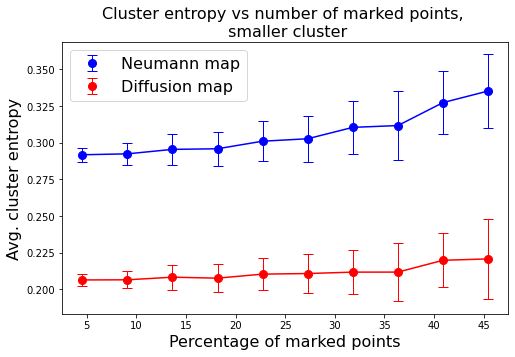

In [17]:
plt.figure(figsize=(8,5))
plt.errorbar(sizes/11, stats_mean[:,2], stats_std[:,2], label='Neumann map', \
            fmt='o', color='blue', ecolor='blue', elinewidth=1, capsize=5, marker='o', markersize=8)
plt.errorbar(sizes/11, stats_mean[:,3], stats_std[:,3], label='Diffusion map', \
            fmt='o', color='red', ecolor='red', elinewidth=1, capsize=5, marker='o', markersize=8)
plt.plot(sizes/11, stats_mean[:,2], color='blue')
plt.plot(sizes/11, stats_mean[:,3], color='red')
plt.legend(fontsize=16)
plt.xlabel('Percentage of marked points', fontsize=16)
plt.ylabel('Avg. cluster entropy', fontsize=16)
plt.title('Cluster entropy vs number of marked points, \n smaller cluster', fontsize=16)
# plt.savefig('Cluster_entropy_smaller_cluster.png')

# Butane

In [133]:
fname = "butane_metad_aligned.npz" #butane_metad.npz DNMTBut.npz butane_hightemp.npz
inData = np.load(fname)
print("Keys in data:")
print(list(inData.keys()))

data_meta = inData["data_all_atom"]
dataMetaD = data_meta
print("Data shape from trajectory:")
print(dataMetaD.shape)
dihedralsMetaD = inData["dihedrals"] # the one dim dihedral angles
potentialMetaD = inData["potential"] # potential related to the particular data point
print(potentialMetaD.shape)
print(dihedralsMetaD.shape)
kbT_roomtemp = inData["kbT_roomtemp"]

Keys in data:
['data', 'data_all_atom', 'dihedrals', 'potential', 'kbT', 'kbT_roomtemp', 'free_energy', 'biasFactor', 'biasWidth', 'height', 'frequency']
Data shape from trajectory:
(200000, 42)
(200000,)
(200000,)


In [134]:
dataMetaD = dataMetaD[::20,:]
dihedralsMetaD = dihedralsMetaD[::20]
potentialMetaD = potentialMetaD[::20]

In [102]:
# Create a boolean vector with all False values
subsamples = np.zeros(dataMetaD.shape[0], dtype=bool)
subsamples[9::10] = True

In [119]:
subsamples = np.logical_or(np.abs(dihedralsMetaD-np.pi) < 0.2, np.abs(dihedralsMetaD-np.pi/3) < 0.1, np.abs(dihedralsMetaD-5*np.pi/3) < 0.1)
subsamples = ~subsamples

In [135]:
def epsilon_net(data, ϵ):

    #initialize the net

    dense = True # parameter that checks whether the net is still dense
    # ϵ = 0.005
    iter = 0 
    ϵ_net = np.array(range(data.shape[1]))
    current_point_index = ϵ_net[0]

    #fill the net

    while dense:
        current_point = data[:,current_point_index] # set current point
        ϵ_ball = np.where(np.linalg.norm(data - np.tile(current_point.reshape(current_point.shape[0],1), 
                                                        (1,data.shape[1])), axis=0) <= ϵ)[0] # get indices for ϵ-ball
        ϵ_net = np.delete(ϵ_net, np.where(np.isin(ϵ_net, ϵ_ball))) # kill elements from the ϵ-ball from the net
        ϵ_net = np.append(ϵ_net, current_point_index) # add the current point at the BACK OF THE QUEUE. THIS IS KEY
        current_point_index = ϵ_net[0] # set current point for killing an epsilon ball in the next iteration
        if current_point_index == 0: # if the current point is the initial one, we are done! 
            dense = False
    return ϵ_net, data[:,ϵ_net]

In [141]:
delta_net, _ = epsilon_net(dataMetaD.T, 1.0)

In [142]:
subsamples = np.ones(dataMetaD.shape[0], dtype=bool)    
subsamples[delta_net] = False

In [143]:
data = dataMetaD[subsamples, :]
dihedrals = dihedralsMetaD[subsamples]
potentials = potentialMetaD[subsamples]
target_measure = np.exp(-potentials/(kbT_roomtemp))

In [145]:
# 1: compute dmap 
# Fiedler vector: 
dmap_obj = diffusion_map.DiffusionMap(alpha=0.5,epsilon=50.0,num_evecs=15, n_neigh=128)
dmap_obj.construct_generator(data.T)

done with kernel!


In [146]:
L_dmap = dmap_obj.get_generator()
dmap, devecs3, devals3 = dmap_obj._construct_diffusion_coords(L_dmap)

computing eigvec matrix


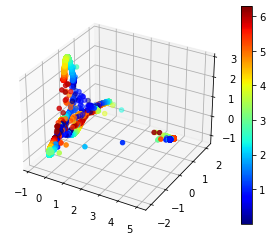

In [147]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
s = ax.scatter(dmap[:,0], dmap[:,1], dmap[:,2], c=dihedrals, cmap='jet')
fig.colorbar(mappable=s)

In [148]:
# 2: neumann eigenmap
nmap_obj = diffusion_map.NeumannMap(alpha=0.5,epsilon=50.0,num_evecs=15)

In [149]:
nmap_obj.construct_generator(dataMetaD.T, subsamples)
L_nmap = nmap_obj.get_generator()
nmap, nevecs3, nevals3 = nmap_obj._construct_diffusion_coords(L_nmap)

computing eigvec matrix


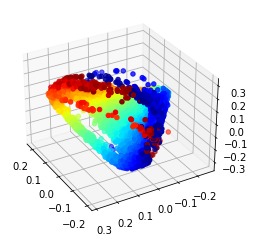

In [150]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(nmap[:,0], nmap[:,1], nmap[:,2], c=dihedrals, cmap='jet')
ax.view_init(azim=150)

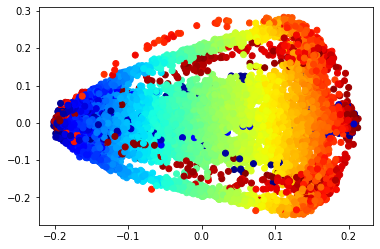

In [151]:
plt.scatter(nmap[:,0], nmap[:,1], c=dihedrals, cmap='jet')

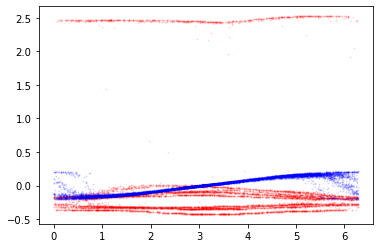

In [153]:
plt.scatter(dihedrals, 0.5*dmap[:,0], color='red', s=1.0, alpha=0.1)
plt.scatter(dihedrals, nmap[:,0], color='blue', s=1.0, alpha=0.1)

In [154]:
dihedrals_indices = np.logical_and(1.0 <= dihedrals, dihedrals <= 5.0)
fit_dihedrals = dihedrals[dihedrals_indices].reshape(-1,1)
fit_dmap = dmap[dihedrals_indices, 0].reshape(-1,1)
fit_nm = nmap[dihedrals_indices, 0].reshape(-1,1)

In [155]:
from sklearn.linear_model import LinearRegression

def calculate_standard_error(X, y, model):
    predictions = model.predict(X)
    residuals = y - predictions
    residual_sum_of_squares = np.sum(residuals**2)
    degrees_of_freedom = X.shape[0] - X.shape[1] - 1
    residual_variance = residual_sum_of_squares / degrees_of_freedom
    X_with_intercept = np.hstack([np.ones((X.shape[0], 1)), X])
    covariance_matrix = residual_variance * np.linalg.inv(X_with_intercept.T @ X_with_intercept)
    standard_errors = np.sqrt(np.diag(covariance_matrix))
    return standard_errors

# Fit linear regression for (fit_dihedrals, fit_dmap)
reg_dmap = LinearRegression().fit(fit_dihedrals, fit_dmap)
dmap_pred = reg_dmap.predict(fit_dihedrals)
r2_dmap = reg_dmap.score(fit_dihedrals, fit_dmap)
se_dmap = calculate_standard_error(fit_dihedrals, fit_dmap, reg_dmap)

# Fit linear regression for (fit_dihedrals, fit_nm)
reg_nm = LinearRegression().fit(fit_dihedrals, fit_nm)
nm_pred = reg_nm.predict(fit_dihedrals)
r2_nm = reg_nm.score(fit_dihedrals, fit_nm)
se_nm = calculate_standard_error(fit_dihedrals, fit_nm, reg_nm)

R² value for (fit_dihedrals, fit_dmap): 5.950326523729288e-07
Standard error for (fit_dihedrals, fit_dmap): [0.05364541 0.01679051]
R² value for (fit_dihedrals, fit_nm): 0.9912658388121556
Standard error for (fit_dihedrals, fit_nm): [3.13373793e-04 9.80830321e-05]


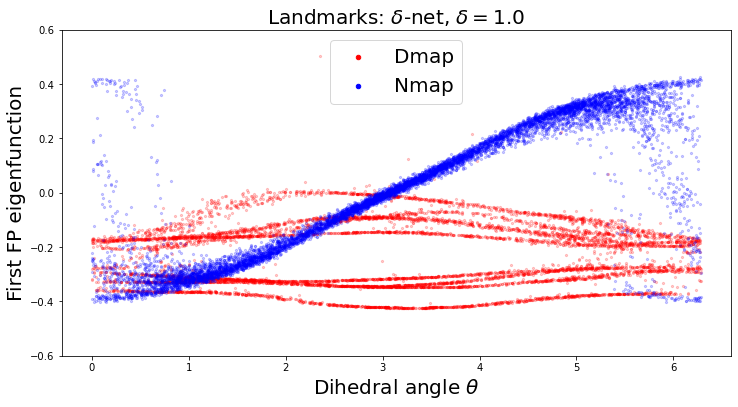

In [156]:
# Print R² values and standard errors
print(f'R² value for (fit_dihedrals, fit_dmap): {r2_dmap}')
print(f'Standard error for (fit_dihedrals, fit_dmap): {se_dmap}')
print(f'R² value for (fit_dihedrals, fit_nm): {r2_nm}')
print(f'Standard error for (fit_dihedrals, fit_nm): {se_nm}')

# Plot the results
plt.figure(figsize=(12, 6))

# Plot for (fit_dihedrals, fit_dmap)
# plt.subplot(1, 2, 1)
plt.scatter(dihedrals, 0.5*dmap[:,0], color = 'red', alpha=0.2, s=5.0)
plt.scatter([],[], color='red', alpha=1.0, s=20.0, label="Dmap")
# plt.plot(fit_dihedrals, 0.5*dmap_pred, color='red', label=f'Dmap, SE = {se_dmap[0]:.4f}')
plt.scatter(dihedrals, 2.0*nmap[:,0], color = 'blue', alpha=0.2, s=5.0)
plt.scatter([],[], color='blue', alpha=1.0, s=20.0, label="Nmap")
# plt.plot(fit_dihedrals, 2.0*nm_pred, color='blue', label=f'Nmap, SE = {se_nm[0]:.4f}')
plt.xlabel(r'Dihedral angle $\theta$', fontsize=20)
plt.ylabel('First FP eigenfunction', fontsize=20)
plt.ylim((-0.6,0.6))
plt.title(r'Landmarks: $\delta$-net, $\delta=1.0$', fontsize=20)
plt.legend(fontsize=20)
plt.savefig('Dihedral_angle_deltanet_subsampling.png')

In [6]:
np.savez('butane_experiment_metastable_subsampling.npz', \
         note="subsample original data by 20. points for neumann embedding are further given by transition states, remove radius 0.2 around pi and 0.1 around pi/3 and 5pi/3", \
         dmap=dmap, devecs3=devecs3, devals3=devals3, nmap=nmap, nevecs3=nevecs3, nevals3=nevals3, \
        alpha=1.0, epsilon=50.0, num_evecs=15)

NameError: name 'devecs3' is not defined